## 1. Installing Required Libraries

In [1]:
!pip install opencv-python

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, data
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.patches as patches
from scipy.ndimage import median_filter
from PIL import Image
from pathlib import Path
import os
from utils import *

## 2. Simulation Result

### 2.1 Forward Model

Image shape: (400, 400) | Observed shape: (400, 400)


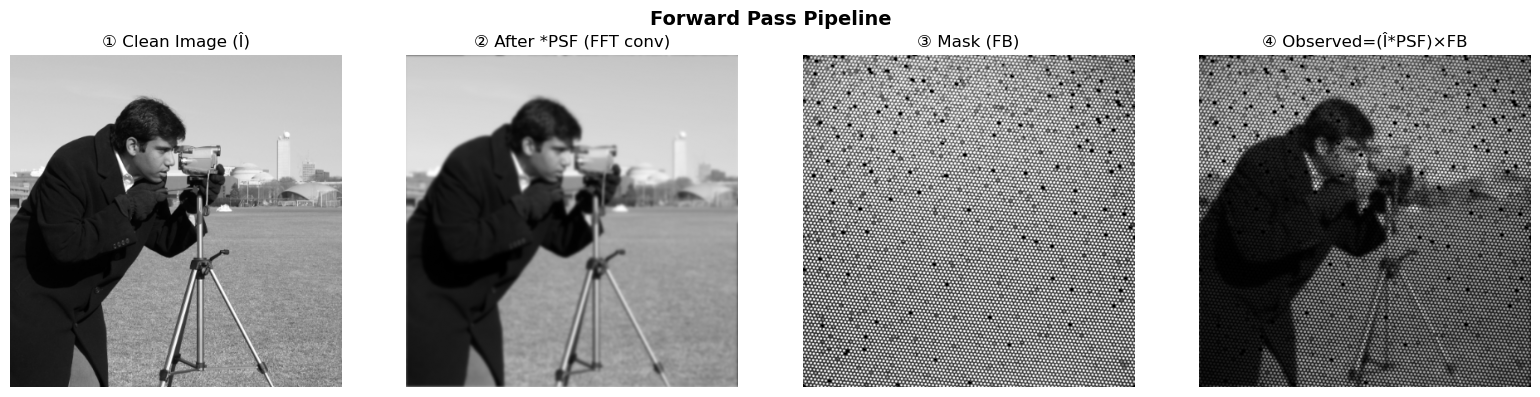

In [11]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================
image = data.camera()  # (512, 512)

mask = io.imread("simulatied-fiber-mask.png")
mask_gray = rgb2gray(mask)

# Crop center 400x400
h, w = mask_gray.shape
start_x = (w - 400) // 2
start_y = (h - 400) // 2
mask_crop = mask_gray[start_y:start_y+400, start_x:start_x+400]

# Resize image to 400x400
image_resized = resize(image, (400, 400), anti_aliasing=True)

H, W = image_resized.shape
device = "cuda" if torch.cuda.is_available() else "cpu"
psf_sigma = 1.5

# ============================================================
# SECTION 2 : FORWARD PASS + VISUALIZATION
# ============================================================

# --- Forward pass ---
H, W        = image_resized.shape
psf_fft     = make_gaussian_psf_freq(psf_sigma, H, W)
image_blurred = apply_psf_freq(image_resized, psf_fft)
observed      = image_blurred * mask_crop

print(f"Image shape: {image_resized.shape} | Observed shape: {observed.shape}")

# --- Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_resized,  cmap='gray'); axes[0].set_title('① Clean Image (Î)');        axes[0].axis('off')
axes[1].imshow(image_blurred,  cmap='gray'); axes[1].set_title('② After *PSF (FFT conv)');  axes[1].axis('off')
axes[2].imshow(mask_crop,      cmap='gray'); axes[2].set_title('③ Mask (FB)');              axes[2].axis('off')
axes[3].imshow(observed,       cmap='gray'); axes[3].set_title('④ Observed=(Î*PSF)×FB');   axes[3].axis('off')
plt.suptitle('Forward Pass Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Convert to tensors ---
observed_tensor = torch.tensor(observed,   dtype=torch.float32).flatten().unsqueeze(-1).to(device)
mask_tensor     = torch.tensor(mask_crop,  dtype=torch.float32).to(device)

In [ ]:
#### ============================================================
# SECTION 3: COORDINATE GRID + MODEL SETUP
# ============================================================
yy, xx = np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W), indexing='ij')
coords = np.stack([xx, yy], axis=-1).reshape(-1, 2)
coords_tensor = torch.tensor(coords, dtype=torch.float32).to(device)

# ── Model selection ──────────────────────────────────────────
encoding_type = 'nerf'
if encoding_type == 'nerf':
    model = PosEncMLP(in_features=2, out_features=1, hidden_features=128, hidden_layers=3,
                      encoding_type="nerf", num_encoding_freqs=10).to(device)
elif encoding_type == 'gaussian':
    model = PosEncMLP(in_features=2, out_features=1, hidden_features=128, hidden_layers=3,
                      encoding_type="gaussian", gauss_scale=5.0).to(device)
elif encoding_type == 'siren':
    model = Siren(in_features=2, out_features=1, hidden_features=128, hidden_layers=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn   = nn.MSELoss()
print(f"Device: {device} | Parameters: {sum(p.numel() for p in model.parameters()):,}")


# Pre-compute PSF once (no grad needed)
psf_fft_torch = make_gaussian_psf_freq_torch(psf_sigma, H, W, device)

# ============================================================
# SECTION 4: TRAINING LOOP WITH TV REGULARIZATION
# ============================================================
num_iters = 25000
lambda_tv = 0.001   # ← tune here: range 1e-4 ~ 5e-4 recommended

loss_history    = []
tv_loss_history = []

for i in range(num_iters+1):
    optimizer.zero_grad()

    # 1. Neural field: (x,y) -> Î
    pred       = torch.sigmoid(model(coords_tensor))   # [H*W, 1], constrained to [0,1]
    pred_image = pred.view(H, W)                       # [H, W] for fft2

    # 2. Convolve with PSF in frequency domain (differentiable)
    pred_blurred = apply_psf_freq_torch(pred_image, psf_fft_torch)   # [H, W]

    # 3. Forward model: (Î * PSF) × mask
    pred_masked = pred_blurred * mask_tensor

    # 4. Data fidelity loss
    mse  = loss_fn(pred_masked.view(-1, 1), observed_tensor)

    # 5. TV regularization on the clean neural output
    tv   = tv_loss(pred.view(1, 1, H, W))

    # 6. Combined loss
    loss = mse + lambda_tv * tv
    loss.backward()
    optimizer.step()

    loss_history.append(mse.item())
    tv_loss_history.append(tv.item())

    if i % 10 == 0:
        print(f"Iter {i:4d}/{num_iters} | MSE: {mse.item():.6f} | TV: {tv.item():.6f} | Total: {loss.item():.6f}")

In [ ]:
# ============================================================
# SECTION 5: RESULTS & VISUALIZATION
# ============================================================

with torch.no_grad():
    pred_clean         = torch.sigmoid(model(coords_tensor)).view(H, W).cpu().numpy()
    pred_image_torch   = torch.tensor(pred_clean, dtype=torch.float32).to(device).view(H, W)
    pred_blurred_final = apply_psf_freq_torch(pred_image_torch, psf_fft_torch).cpu().numpy()
    pred_masked_final  = pred_blurred_final * mask_crop

# ── Normalize to [0, 1] ──────────────────────────────────────
def to01(arr):
    a = arr.astype(np.float32)
    return a / 255.0 if a.max() > 1.0 else a

gt   = to01(image_resized)
obs  = to01(observed)
pred = to01(pred_clean)

# ── Median-filtered reconstruction ───────────────────────────
pred_median = median_filter(pred, size=k_size_median)

# ── Metrics ──────────────────────────────────────────────────
psnr_obs    = psnr(gt, obs,         data_range=1.0)
ssim_obs    = ssim(gt, obs,         data_range=1.0)
psnr_pred   = psnr(gt, pred,        data_range=1.0)
ssim_pred   = ssim(gt, pred,        data_range=1.0)
psnr_median = psnr(gt, pred_median, data_range=1.0)
ssim_median = ssim(gt, pred_median, data_range=1.0)

# ── Crop settings (programmable) ─────────────────────────────
crop_y = 50    # top-left row
crop_x = 110   # top-left col
crop_h = 120   # height in pixels
crop_w = 120   # width  in pixels

def crop(arr):
    return arr[crop_y:crop_y+crop_h, crop_x:crop_x+crop_w]

# ── Loss curves (log10): MSE, TV, Total ──────────────────────
loss_arr    = np.array(loss_history)
tv_arr      = np.array(tv_loss_history)
total_arr   = loss_arr + lambda_tv * tv_arr

plt.figure(figsize=(9, 3))
plt.plot(np.log10(loss_arr),   label='MSE loss')
plt.plot(np.log10(tv_arr),     label=f'TV loss (×{lambda_tv})', alpha=0.7)
plt.plot(np.log10(total_arr),  label='Total loss', linestyle='--', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('log₁₀(Loss)')
plt.title('Training Loss (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Main figure: 2 rows × 4 cols ─────────────────────────────
images = [gt, obs, pred, to01(pred_masked_final)]
crops  = [crop(im) for im in images]

titles = [
    'Ground Truth',
    f'Measurement\nPSNR={psnr_obs:.2f}dB  SSIM={ssim_obs:.4f}',
    f'Recon\nPSNR={psnr_pred:.2f}dB  SSIM={ssim_pred:.4f}',
    'Recon Forward Check',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (img, crp, title) in enumerate(zip(images, crops, titles)):
    # ── Row 0: full image with crop rectangle ────────────────
    ax = axes[0, col]
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    rect = patches.Rectangle(
        (crop_x, crop_y), crop_w, crop_h,
        linewidth=1.5, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

    # ── Row 1: zoomed crop ───────────────────────────────────
    axes[1, col].imshow(crp, cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

# ── Console summary ──────────────────────────────────────────
print("Shape / Min / Max")
for name, arr in [('GT', gt), ('Observed', obs), ('Pred clean', pred),
                  ('Pred median', pred_median), ('Pred masked', to01(pred_masked_final))]:
    print(f"  {name:12s}: {arr.shape}  [{arr.min():.3f}, {arr.max():.3f}]")
print(f"\nObserved     — PSNR: {psnr_obs:.4f} dB  |  SSIM: {ssim_obs:.4f}")
print(f"Pred clean   — PSNR: {psnr_pred:.4f} dB  |  SSIM: {ssim_pred:.4f}")
print(f"Pred median  — PSNR: {psnr_median:.4f} dB  |  SSIM: {ssim_median:.4f}")

## 3. Experimental Data (PyFiberBundle)

Original imgs: (960, 1280, 12) 3 255
Original calibImg: (960, 1280) 3 255
Cropped calibImg: (544, 544) 20 255
Cropped imgs: (544, 544, 12) 7 255
Normalized imgs: (544, 544, 12) 0.02745098 1.0
Normalized calibImg: (544, 544) 0.078431375 1.0


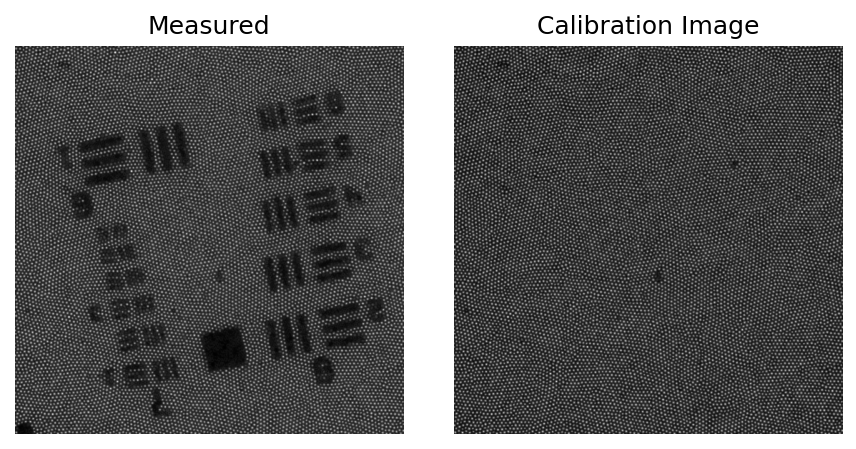

In [12]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

dataFolder = Path('./Resolution Chart/')
backFile   = Path('./Resolution Chart - BG.tif')

files = [f.path for f in os.scandir(dataFolder)]
nImages = 12

if nImages is None:
    nImages = len(files)

# ----------------------------
# Load images
# ----------------------------
img = np.array(Image.open(files[0]))
imSize = img.shape

imgs = np.zeros((imSize[0], imSize[1], nImages), dtype='uint8')

for idx, fName in enumerate(files[:nImages]):
    imgs[:, :, idx] = np.array(Image.open(fName))

print('Original imgs:', imgs.shape, np.min(imgs), np.max(imgs))

# ----------------------------
# Load calibration image
# ----------------------------
calibImg = np.array(Image.open(backFile))
print('Original calibImg:', calibImg.shape, np.min(calibImg), np.max(calibImg))

# ----------------------------
# Crop
# ----------------------------
crop_box = (358, 208, 902, 752)  # (left, upper, right, lower)

calibImg = calibImg[crop_box[1]:crop_box[3], crop_box[0]:crop_box[2]]
imgs     = imgs[crop_box[1]:crop_box[3], crop_box[0]:crop_box[2], :]

print('Cropped calibImg:', calibImg.shape, np.min(calibImg), np.max(calibImg))
print('Cropped imgs:', imgs.shape, np.min(imgs), np.max(imgs))

# ----------------------------
# Normalize to [0, 1]
# ----------------------------
imgs     = imgs.astype(np.float32) / 255.0
calibImg = calibImg.astype(np.float32) / 255.0

print('Normalized imgs:', np.shape(imgs), np.min(imgs), np.max(imgs))
print('Normalized calibImg:', np.shape(calibImg), np.min(calibImg), np.max(calibImg))

# ----------------------------
# Visualization
# ----------------------------
plt.figure(dpi=150, figsize=(6,3))

plt.subplot(1, 2, 1)
plt.imshow(imgs[:, :, 8], cmap='gray')
plt.title('Measured')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(calibImg, cmap='gray')
plt.title('Calibration Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#### ============================================================
# SECTION 2: COORDINATE GRID + MODEL SETUP
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
observed = imgs[:, :, 8]
observed_tensor = torch.tensor(observed,   dtype=torch.float32).flatten().unsqueeze(-1).to(device)
mask_tensor     = torch.tensor(calibImg,  dtype=torch.float32).to(device)

H, W        = observed.shape
yy, xx = np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W), indexing='ij')
coords = np.stack([xx, yy], axis=-1).reshape(-1, 2)
coords_tensor = torch.tensor(coords, dtype=torch.float32).to(device)

# ── Model selection ──────────────────────────────────────────
encoding_type = 'nerf'
if encoding_type == 'nerf':
    model = PosEncMLP(in_features=2, out_features=1, hidden_features=128, hidden_layers=3,
                      encoding_type="nerf", num_encoding_freqs=10).to(device)
elif encoding_type == 'gaussian':
    model = PosEncMLP(in_features=2, out_features=1, hidden_features=128, hidden_layers=3,
                      encoding_type="gaussian", gauss_scale=5.0).to(device)
elif encoding_type == 'siren':
    model = Siren(in_features=2, out_features=1, hidden_features=128, hidden_layers=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn   = nn.MSELoss()
print(f"Device: {device} | Parameters: {sum(p.numel() for p in model.parameters()):,}")


# Pre-compute PSF once (no grad needed)
psf_sigma = 0.5
psf_fft_torch = make_gaussian_psf_freq_torch(psf_sigma, H, W, device)

# ============================================================
# SECTION 3: TRAINING LOOP WITH TV REGULARIZATION
# ============================================================
num_iters = 25000
lambda_tv = 0.05   # ← tune here: range 1e-4 ~ 5e-4 recommended

loss_history    = []
tv_loss_history = []

for i in range(num_iters+1):
    optimizer.zero_grad()

    # 1. Neural field: (x,y) -> Î
    pred       = torch.sigmoid(model(coords_tensor))   # [H*W, 1], constrained to [0,1]
    pred_image = pred.view(H, W)                       # [H, W] for fft2

    # 2. Convolve with PSF in frequency domain (differentiable)
    pred_blurred = apply_psf_freq_torch(pred_image, psf_fft_torch)   # [H, W]

    # 3. Forward model: (Î * PSF) × mask
    pred_masked = pred_blurred * mask_tensor

    # 4. Data fidelity loss
    mse  = loss_fn(pred_masked.view(-1, 1), observed_tensor)

    # 5. TV regularization on the clean neural output
    tv   = tv_loss(pred.view(1, 1, H, W))

    # 6. Combined loss
    loss = mse + lambda_tv * tv
    loss.backward()
    optimizer.step()

    loss_history.append(mse.item())
    tv_loss_history.append(tv.item())

    if i % 10 == 0:
        print(f"Iter {i:4d}/{num_iters} | MSE: {mse.item():.6f} | TV: {tv.item():.6f} | Total: {loss.item():.6f}")

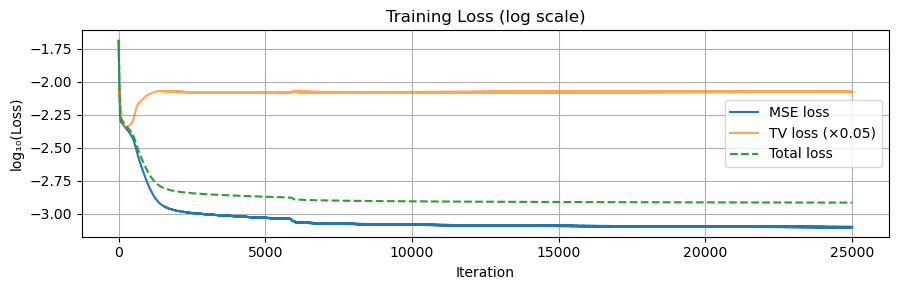

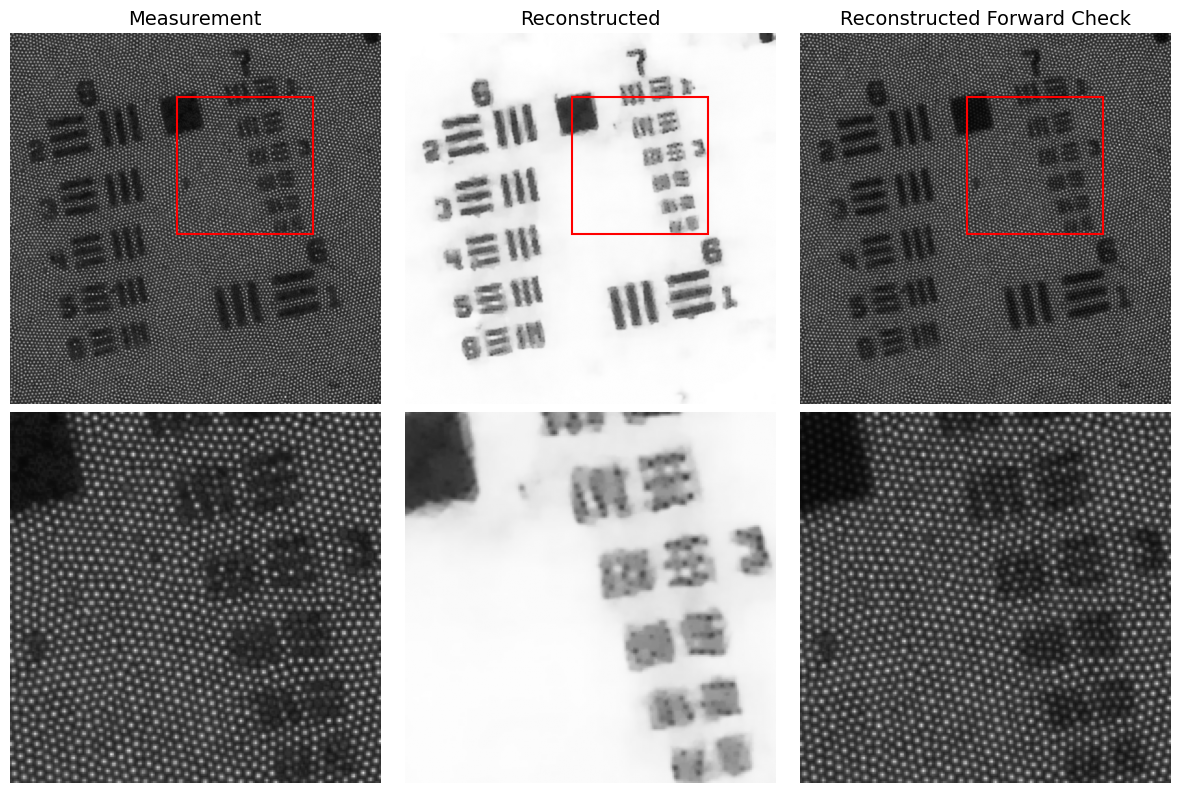

Shape / Min / Max
  Observed    : (544, 544)  [0.031, 1.000]
  Pred clean  : (544, 544)  [0.125, 0.999]
  Pred median : (544, 544)  [0.156, 0.998]
  Pred masked : (544, 544)  [0.023, 0.994]


In [8]:
# ============================================================
# SECTION 4: RESULTS & VISUALIZATION
# ============================================================
with torch.no_grad():
    pred_clean         = torch.sigmoid(model(coords_tensor)).view(H, W).cpu().numpy()
    pred_image_torch   = torch.tensor(pred_clean, dtype=torch.float32).to(device).view(H, W)
    pred_blurred_final = apply_psf_freq_torch(pred_image_torch, psf_fft_torch).cpu().numpy()
    pred_masked_final  = pred_blurred_final * calibImg

# ── Normalize to [0, 1] ──────────────────────────────────────
def to01(arr):
    a = arr.astype(np.float32)
    return a / 255.0 if a.max() > 1.0 else a

obs  = to01(observed)
pred = to01(pred_clean)

# ── Median-filtered reconstruction ───────────────────────────
k_size_median = 4
pred_median = median_filter(pred, size=k_size_median)

# ── Crop settings (programmable) ─────────────────────────────
crop_y = 250    # top-left row
crop_x = 100   # top-left col
crop_h = 200   # height in pixels
crop_w = 200   # width  in pixels

def crop(arr):
    return arr[crop_y:crop_y+crop_h, crop_x:crop_x+crop_w]

# ── Loss curves (log10): MSE, TV, Total ──────────────────────
loss_arr    = np.array(loss_history)
tv_arr      = np.array(tv_loss_history)
total_arr   = loss_arr + lambda_tv * tv_arr

plt.figure(figsize=(9, 3))
plt.plot(np.log10(loss_arr),   label='MSE loss')
plt.plot(np.log10(tv_arr),     label=f'TV loss (×{lambda_tv})', alpha=0.7)
plt.plot(np.log10(total_arr),  label='Total loss', linestyle='--', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('log₁₀(Loss)')
plt.title('Training Loss (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Main figure: 2 rows × 4 cols ─────────────────────────────
images = [obs, pred, to01(pred_masked_final)]
# images = [obs, pred_median, to01(pred_masked_final)]
crops  = [crop(im) for im in images]

titles = [
    'Measurement',
    'Reconstructed',
    'Reconstructed Forward Check',
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

H, W = images[0].shape  # original image size

for col, (img, crp, title) in enumerate(zip(images, crops, titles)):
    
    # ── Rotate images ────────────────────────────────────────
    img_rot = np.rot90(img, 2)
    crp_rot = np.rot90(crp, 2)

    # ── Adjust rectangle for 180° rotation ───────────────────
    new_x = W - (crop_x + crop_w)
    new_y = H - (crop_y + crop_h)

    # ── Row 0: full image with corrected rectangle ───────────
    ax = axes[0, col]
    ax.imshow(img_rot, cmap='gray', vmin=0, vmax=1)

    rect = patches.Rectangle(
        (new_x, new_y), crop_w, crop_h,
        linewidth=1.5, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    ax.set_title(title, fontsize=14)
    ax.axis('off')

    # ── Row 1: rotated crop ──────────────────────────────────
    axes[1, col].imshow(crp_rot, cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

# ── Console summary ──────────────────────────────────────────
print("Shape / Min / Max")
for name, arr in [('Observed', obs), ('Pred clean', pred),
                  ('Pred median', pred_median), ('Pred masked', to01(pred_masked_final))]:
    print(f"  {name:12s}: {arr.shape}  [{arr.min():.3f}, {arr.max():.3f}]")

In [9]:
# ============================================================
# SECTION 5: Saving
# ============================================================
import pickle

# Prepare your data
images = [obs, pred, to01(pred_masked_final)]

loss_arr  = np.array(loss_history)
tv_arr    = np.array(tv_loss_history)
total_arr = loss_arr + lambda_tv * tv_arr

# Bundle everything into a dictionary
data_to_save = {
    "images": images,
    "obs": obs,
    "pred": pred,
    "pred_masked_final": to01(pred_masked_final),
    "loss_arr": loss_arr,
    "tv_arr": tv_arr,
    "total_arr": total_arr,
    "lambda_tv": lambda_tv
}

# Save to pickle file
with open("Resolution_chart4.pkl", "wb") as f:
    pickle.dump(data_to_save, f)